# Setup and Installation

Run this cell first to ensure all required packages are installed.

In [1]:
import sys
import subprocess

def install_requirements():
    """
    Install all required packages for the fraud detection notebook.
    This includes data processing, machine learning, and visualization libraries.
    """
    
    # Core data science packages
    packages = [
        'pandas',                    # Data manipulation and analysis
        'numpy',                     # Numerical computing
        'scikit-learn',              # Machine learning algorithms
        'matplotlib',                # Plotting and visualization
        'seaborn',                   # Statistical data visualization
        'tqdm',                      # Progress bars
        
        # Deep learning and graph neural networks
        'torch',                     # PyTorch deep learning framework
        'torch-geometric',           # Graph Neural Network library
        'torch-scatter',             # Scatter operations for PyTorch
        'torch-sparse',              # Sparse tensor operations
        
        # Data download and file handling
        'kagglehub',                 # Kaggle dataset downloads
        'gdown',                     # Google Drive file downloads
        
        # Graph visualization
        'networkx',                  # Graph/network analysis
        'pyvis',                     # Interactive network visualizations
    ]
    
    print("="*80)
    print("INSTALLING REQUIRED PACKAGES FOR FRAUD DETECTION NOTEBOOK")
    print("="*80)
    print(f"\nTotal packages to install: {len(packages)}\n")
    
    for i, package in enumerate(packages, 1):
        print(f"[{i}/{len(packages)}] Installing {package}...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", package],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.PIPE
            )
            print(f"  ✓ {package} installed successfully")
        except subprocess.CalledProcessError as e:
            print(f"  ⚠ Warning: Failed to install {package}")
            print(f"    Error: {e.stderr.decode() if e.stderr else 'Unknown error'}")
    
    print("\n" + "="*80)
    print("INSTALLATION COMPLETE")
    print("="*80)
    print("\n✓ All packages installed. You can now run the notebook cells below.")
    print("\nNote: If you encounter any import errors, you may need to restart the kernel.")

# Run the installation
install_requirements()

INSTALLING REQUIRED PACKAGES FOR FRAUD DETECTION NOTEBOOK

Total packages to install: 14

[1/14] Installing pandas...
  ✓ pandas installed successfully
[2/14] Installing numpy...
  ✓ numpy installed successfully
[3/14] Installing scikit-learn...
  ✓ scikit-learn installed successfully
[4/14] Installing matplotlib...
  ✓ matplotlib installed successfully
[5/14] Installing seaborn...
  ✓ seaborn installed successfully
[6/14] Installing tqdm...
  ✓ tqdm installed successfully
[7/14] Installing torch...
  ✓ torch installed successfully
[8/14] Installing torch-geometric...
  ✓ torch-geometric installed successfully
[9/14] Installing torch-scatter...
  ✓ torch-scatter installed successfully
[10/14] Installing torch-sparse...
  ✓ torch-sparse installed successfully
[11/14] Installing kagglehub...
  ✓ kagglehub installed successfully
[12/14] Installing gdown...
  ✓ gdown installed successfully
[13/14] Installing networkx...
  ✓ networkx installed successfully
[14/14] Installing pyvis...
  ✓ py

## Alternative Installation Methods

**Option 1: Run the cell above** - Installs packages directly from within the notebook.

**Option 2: Use requirements.txt** - Install from command line:
```bash
pip install -r requirements.txt
```

**Option 3: Individual packages** - Install specific packages:
```bash
pip install pandas numpy torch torch-geometric scikit-learn matplotlib networkx pyvis kagglehub gdown tqdm
```

**Important Notes:**
- PyTorch Geometric (`torch-geometric`) may require additional dependencies (`torch-scatter`, `torch-sparse`) depending on your system
- For GPU support, install the CUDA-enabled version of PyTorch from [pytorch.org](https://pytorch.org)
- After installation, restart the kernel to ensure all packages are properly loaded

# Download banksim dataset from kaggle

**Citation:** Lopez-Rojas, Edgar Alonso; Axelsson, Stefan. *Banksim: A bank payments simulator for fraud detection research*. Inproceedings 26th European Modeling and Simulation Symposium, EMSS 2014, Bordeaux, France, pp. 144–152, Dime University of Genoa, 2014, ISBN: 9788897999324. https://www.researchgate.net/publication/265736405_BankSim_A_Bank_Payment_Simulation_for_Fraud_Detection_Research

In [2]:
import kagglehub
import os
import shutil
from csv_to_gzip import csv_to_gzip

# Check for required files in banksim directory
files_to_check = [
    "banksim/bs140513_032310.csv.gz",
    "banksim/bsNET140513_032310.csv.gz"
]

files_exist = all(os.path.exists(f) for f in files_to_check)

if files_exist:
    print("Both required files found. Skipping download.")
else:
    print("Required files missing. Downloading dataset...")
    path = kagglehub.dataset_download("ealaxi/banksim1")
    shutil.copytree(path, "banksim", dirs_exist_ok=True)
    print("Downloaded dataset to 'banksim'.")
    
    # Compress CSV files to gzip
    for csv_file in ['bs140513_032310.csv', 'bsNET140513_032310.csv']:
        csv_path = os.path.join("banksim", csv_file)
        if os.path.exists(csv_path):
            csv_to_gzip(csv_path)
            print(f"Compressed {csv_file} to {csv_file}.gz")

print("Path to dataset files:", "banksim")

Both required files found. Skipping download.
Path to dataset files: banksim


In [3]:
import os
import pandas as pd

# List files in the banksim dataset directory
banksim_path = "banksim"
banksim_files = os.listdir("banksim")
print(f"Files in banksim dataset directory:\n")

for file in banksim_files:
    file_path = os.path.join(banksim_path, file)
    print(f"{'='*50}")
    print(f"File: {file}")
    print(f"{'='*50}")
    
    if file.endswith('.csv.gz'):
        df_temp = pd.read_csv(file_path)
        print(f"Shape: {df_temp.shape}")
        print(f"Columns: {list(df_temp.columns)}")
        print(f"\nFirst few rows:\n{df_temp.head()}")
        print(f"\nData types:\n{df_temp.dtypes}")

        # Count fraud and non-fraud in the banksim dataset
        fraud_count = (df_temp['fraud'] == 1).sum()
        non_fraud_count = (df_temp['fraud'] == 0).sum()

        print("BankSim Dataset - Fraud Distribution:")
        print(f"  Fraud: {fraud_count}")
        print(f"  Non-Fraud: {non_fraud_count}")
        print(f"  Total: {len(df_temp)}")
        print(f"  Fraud Percentage: {fraud_count / len(df_temp) * 100:.2f}%")
    else:
        print(f"File type: {os.path.splitext(file)[1]}")
        print(f"File size: {os.path.getsize(file_path)} bytes")
    
    print("\n")


Files in banksim dataset directory:

File: bsNET140513_032310.csv.gz
Shape: (594643, 5)
Columns: ['Source', 'Target', 'Weight', 'typeTrans', 'fraud']

First few rows:
          Source         Target  Weight            typeTrans  fraud
0  'C1093826151'   'M348934600'    4.55  'es_transportation'      0
1   'C352968107'   'M348934600'   39.68  'es_transportation'      0
2  'C2054744914'  'M1823072687'   26.89  'es_transportation'      0
3  'C1760612790'   'M348934600'   17.25  'es_transportation'      0
4   'C757503768'   'M348934600'   35.72  'es_transportation'      0

Data types:
Source        object
Target        object
Weight       float64
typeTrans     object
fraud          int64
dtype: object
BankSim Dataset - Fraud Distribution:
  Fraud: 7200
  Non-Fraud: 587443
  Total: 594643
  Fraud Percentage: 1.21%


File: bs140513_032310.csv.gz
Shape: (594643, 10)
Columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

First fe

# Download the scotiabank data files

In [4]:
import gdown
import zipfile
import os
from csv_to_gzip import csv_to_gzip

data_path = "data"
# Check for required files in data directory
files_to_check = [
    "data/labels.csv.gz",
    "data/kyc_individual.csv.gz",
    "data/kyc_smallbusiness.csv.gz",
    "data/card.csv.gz"
]

files_exist = all(os.path.exists(f) for f in files_to_check)
files_exist = files_exist and os.path.isdir(data_path) and len(os.listdir(data_path)) == 12

if files_exist:
    print("Required files found. Skipping download.")
else:
    print("Required files missing. Downloading dataset...")
    
    # Download data.zip
    url = "https://drive.google.com/file/d/1A7w3GqZTCVsv-A8gXj5NKV2FNc0zoduG/view?usp=sharing"
    zip_path = "data.zip"

    print("Downloading data.zip...")
    gdown.download(url, zip_path, fuzzy=True)
    print("Download complete.")

    # Extract the zip file
    print("Extracting data.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")
    print("Extraction complete.")

    # Compress all CSV files in the data directory to .csv.gz
    print("Compressing CSV files to gzip...")
    for filename in os.listdir(data_path):
        if filename.endswith('.csv'):
            csv_path = os.path.join(data_path, filename)
            csv_to_gzip(csv_path)
            print(f"Compressed {filename} to {filename}.gz")
            os.remove(csv_path)

    # Clean up the zip file
    os.remove(zip_path)
    print("Cleaned up data.zip")

print("Data files ready in 'data' directory")


Required files found. Skipping download.
Data files ready in 'data' directory


# Prepare transaction nodes for Graph Attention Network

Combine the BankSim and Scotiabank transactions into a unified master pool aligned to the card schema:

**Schema**
[transaction_id, customer_id, amount_cad, debit_credit, transaction_datetime, merchant_category, ecommerce_ind, cash_indicator, country, province, city, is_fraud, source_dataset, time_delta, velocity_24h, cust_idx, cat_idx, city_idx]

**Field definitions**
- **transaction_id**: Unique transaction identifier (BankSim uses `BS_{i}`).
- **customer_id**: Unique customer identifier.
- **amount_cad**: Transaction amount in CAD (BankSim amounts multiplied by 1.62 from EUR).
- **debit_credit**: Debit/credit flag (BankSim uses `debit`; Scotiabank uses source values).
- **transaction_datetime**: Transaction timestamp (BankSim derived from `step`).
- **merchant_category**: Mapped industry category or transfer type.
- **ecommerce_ind**: 1 if e-commerce (e.g., tech/content), else 0.
- **cash_indicator**: 1 for cash-like activity (ABM), else 0.
- **country/province/city**: Location fields (BankSim defaults to Canada/Ontario/Toronto; transfers use N/A).
- **is_fraud**: Fraud label (BankSim from `fraud`; Scotiabank from `labels`, default -1 if unknown).
- **source_dataset**: Origin dataset (banksim, scotia_card, scotia_abm, scotia_transfer).
- **time_delta**: Minutes since the customer’s previous transaction (0 for first transaction).
- **velocity_24h**: Count of customer transactions in the trailing 24 hours (including current).
- **cust_idx/cat_idx/city_idx**: Integer-encoded indices for graph nodes.

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import gc  # Garbage Collector

def get_mapping(series):
    unique_vals = series.unique()
    return {val: i for i, val in enumerate(unique_vals)}, len(unique_vals)

def build_master_transaction_pool(banksim_path, data_path):
    # --- 1. Helper for Categorical Conversion ---
    def shrink_and_categorize(df):
        for col in df.select_dtypes(include=['object']):
            df[col] = df[col].astype('category')
        for col in df.select_dtypes(include=['float']):
            df[col] = pd.to_numeric(df[col], downcast='float')
        for col in df.select_dtypes(include=['integer']):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        return df

    print("Loading Banksim...")
    bs = pd.read_csv(os.path.join(banksim_path, 'bs140513_032310.csv.gz'))
    bs.columns = bs.columns.str.replace("'", "")
    
    # Process column by column to save peak RAM
    for col in ['customer', 'category']:
        bs[col] = bs[col].str.replace("'", "").astype('category')
    
    start_date = datetime(year=2024, month=11, day=1)
    
    # Build BS Master and immediately drop the source
    bs_master = pd.DataFrame({
        'transaction_id': np.arange(len(bs), dtype='int32'),
        'customer_id': bs['customer'],
        'amount_cad': (bs['amount'] * 1.62).astype('float32'),
        'debit_credit': 'debit',
        'transaction_datetime': bs['step'].apply(lambda x: start_date + timedelta(days=x)),
        'merchant_category': bs['category'], # We will map this later to save RAM
        'ecommerce_ind': np.where(bs['category'].isin(['es_tech', 'es_contents']), 1, 0).astype('int8'),
        'cash_indicator': np.int8(0), 
        'country': 'Canada', 'province': 'Ontario', 'city': 'Toronto',
        'is_fraud': bs['fraud'].astype('int8'),
        'source_dataset': 'banksim'
    })
    del bs; gc.collect()

    # --- 2. Process Scotia Datasets ---
    labels_df = pd.read_csv(os.path.join(data_path, 'labels.csv.gz'))
    labels_df['customer_id'] = labels_df['customer_id'].astype('category')

    def process_scotia(name, filename):
        print(f" Processing {name}...")
        df = pd.read_csv(os.path.join(data_path, filename))
        df['customer_id'] = df['customer_id'].astype('category')
        df = df.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
        df['is_fraud'] = df['label'].fillna(-1).astype('int8')
        df['source_dataset'] = name
        df.drop(columns=['label'], inplace=True)
        return shrink_and_categorize(df)

    card_master = process_scotia('scotia_card', 'card.csv.gz')
    card_master['cash_indicator'] = np.int8(0)
    
    abm_master = process_scotia('scotia_abm', 'abm.csv.gz')
    abm_master['merchant_category'] = 'ATM_WITHDRAWAL'
    abm_master['ecommerce_ind'] = np.int8(0)
    abm_master['cash_indicator'] = np.int8(1)

    # Combine "Others" sequentially
    others_list = []
    for name in ['cheque', 'eft', 'emt', 'westernunion', 'wire']:
        tmp = process_scotia(f'scotia_{name}', f'{name}.csv.gz')
        tmp['merchant_category'] = name.upper()
        others_list.append(tmp)
    
    others = pd.concat(others_list, axis=0)
    others['country'], others['province'], others['city'] = 'Canada', 'N/A', 'N/A'
    others['ecommerce_ind'] = np.int8(0)
    others['cash_indicator'] = np.int8(0)
    del others_list, labels_df; gc.collect()

    # --- 3. The Final Merge ---
    print("Final merge starting...")
    # By now, almost all columns are 'category' or 'int8', making this merge 5x lighter
    master_pool = pd.concat([bs_master, card_master, abm_master, others], axis=0, ignore_index=True)
    del bs_master, card_master, abm_master, others; gc.collect()

    # --- 4. Final Cleanup & Velocity ---
    master_pool['city'] = master_pool['city'].fillna('UNKNOWN').astype('category')
    master_pool['transaction_datetime'] = pd.to_datetime(master_pool['transaction_datetime'])
    master_pool = master_pool.sort_values(['customer_id', 'transaction_datetime'])

    # Calculate time delta since last transaction (in minutes)
    master_pool['time_delta'] = master_pool.groupby('customer_id')['transaction_datetime'].diff().dt.total_seconds() / 60
    master_pool['time_delta'] = master_pool['time_delta'].fillna(0)  # First transaction has no delta
    print("Computed time delta")

    print("Computing 24h velocity...")
    # Use lowercase '24h' to avoid the error from the previous step
    master_pool = master_pool.set_index('transaction_datetime')
    master_pool['velocity_24h'] = (
        master_pool.groupby('customer_id')['amount_cad']
        .rolling(window='24h')
        .count()
        .reset_index(level=0, drop=True)
        .astype('int32')
    )
    master_pool = master_pool.reset_index()

    return shrink_and_categorize(master_pool)

def get_maps(master_pool):
    cust_map, num_cust = get_mapping(master_pool['customer_id'])
    cat_map, num_cat = get_mapping(master_pool['merchant_category'])
    city_map, num_city = get_mapping(master_pool['city'].str.upper().fillna('UNKNOWN'))
    master_pool['cust_idx'] = master_pool['customer_id'].map(cust_map)
    master_pool['cat_idx'] = master_pool['merchant_category'].map(cat_map)
    master_pool['city_idx'] = master_pool['city'].str.upper().fillna('UNKNOWN').map(city_map)
    return cust_map, cat_map, city_map, num_cust, num_cat, num_city

master_path = "master_transaction_pool.csv.gz"
if not os.path.exists(master_path):
    print("Building master transaction pool")
    master_pool = build_master_transaction_pool(banksim_path, data_path)
    print("Mapping started")
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)
    print("Saving started")
    master_pool.to_csv(master_path, index=False, compression="gzip")
else:
    print("Reading started")
    master_pool = pd.read_csv(master_path, compression="gzip")
    print("Mapping started")
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)
master_pool.head()

Reading started


/tmp/ipykernel_385481/2588850912.py:132: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_pool = pd.read_csv(master_path, compression="gzip")


Mapping started


,transaction_datetime,transaction_id,customer_id,amount_cad,debit_credit,merchant_category,ecommerce_ind,cash_indicator,country,province,city,is_fraud,source_dataset,time_delta,velocity_24h,cust_idx,cat_idx,city_idx
0,2024-12-01,80563,C1000148617,233.069397,debit,es_otherservices,0,0,Canada,Ontario,Toronto,0,banksim,0.0,1,0,0,0
1,2024-12-09,105386,C1000148617,27.037800,debit,es_sportsandtoys,0,0,Canada,Ontario,Toronto,0,banksim,11520.0,1,0,1,0
2,2024-12-13,117326,C1000148617,91.011597,debit,es_otherservices,0,0,Canada,Ontario,Toronto,0,banksim,5760.0,1,0,0,0
3,2024-12-14,120414,C1000148617,23.878799,debit,es_tech,1,0,Canada,Ontario,Toronto,0,banksim,1440.0,1,0,2,0
4,2024-12-15,124902,C1000148617,76.820396,debit,es_transportation,0,0,Canada,Ontario,Toronto,0,banksim,1440.0,1,0,3,0


# Prepare customer nodes for Graph Attention Network

We group individual customers and small businesses into one node type for simplicity. 

**Schema:** customer_id, age, income, tenure, sales, emp_count, is_biz

**Field definitions**
- **customer_id**: Unique customer identifier across KYC and BankSim sources.
- **age**: Customer age (years); derived from KYC birth dates or BankSim age buckets, with median imputation for missing.
- **income**: Annual income (or reported income proxy); missing values filled with the KYC median.
- **tenure**: Customer tenure in days since onboarding; defaults to 730 days if unknown.
- **sales**: Annual sales for small businesses; 0 for individuals, median-imputed when missing.
- **emp_count**: Number of employees for small businesses; 0 for individuals, median-imputed when missing.
- **is_biz**: 1 for small business customers, 0 for individuals.

In [6]:
# Build customers_df by merging KYC individuals + small businesses, then add BankSim customers
# Expected columns: ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']

# Helper to compute tenure if onboard_date exists
def compute_tenure_days(df, date_col='onboard_date'):
    if date_col in df.columns:
        return (pd.Timestamp('2025-01-31') - pd.to_datetime(df[date_col], errors='coerce')).dt.days
    return pd.Series([np.nan] * len(df))

def build_customer_transaction_pool():
    # Load KYC data
    kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'))
    kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'))

    # Normalize column names
    kyc_ind.columns = kyc_ind.columns.str.lower()
    kyc_biz.columns = kyc_biz.columns.str.lower()

    # Prefer birth_date-derived ages when available
    if 'birth_date' in kyc_ind.columns:
        birth_dates = pd.to_datetime(kyc_ind['birth_date'], errors='coerce')
        derived_age = (pd.Timestamp('2025-01-31') - birth_dates).dt.days / 365.25
        if 'age' in kyc_ind.columns:
            raw_age = pd.to_numeric(kyc_ind['age'], errors='coerce')
            ind_age = raw_age.fillna(derived_age)
        else:
            ind_age = derived_age
    else:
        if 'age' in kyc_ind.columns:
            ind_age = pd.to_numeric(kyc_ind['age'], errors='coerce')
        else:
            ind_age = pd.Series([np.nan] * len(kyc_ind))

    # Prepare individuals
    ind = pd.DataFrame({
        'customer_id': kyc_ind['customer_id'].astype(str),
        'age': ind_age,
        'income': kyc_ind.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_ind),
        'sales': 0.0,
        'emp_count': 0.0,
        'is_biz': 0
    })

    # Prepare small businesses
    biz = pd.DataFrame({
        'customer_id': kyc_biz['customer_id'].astype(str),
        'age': np.nan,
        'income': kyc_biz.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_biz),
        'sales': kyc_biz.get('sales', 0.0),
        'emp_count': kyc_biz.get('emp_count', 0.0),
        'is_biz': 1
    })

    # Medians for imputation
    median_income = ind['income'].median()
    median_age = ind['age'].median()
    if pd.isna(median_age):
        median_age = 40.0
    median_sales = biz['sales'].median() if 'sales' in biz else 0.0
    median_emp = biz['emp_count'].median() if 'emp_count' in biz else 0.0

    # Fill missing in KYC
    for df in (ind, biz):
        df['income'] = df['income'].fillna(median_income)
        df['age'] = df['age'].fillna(median_age)
        df['tenure'] = df['tenure'].fillna(730)  # 2 years
        df['sales'] = df['sales'].fillna(median_sales)
        df['emp_count'] = df['emp_count'].fillna(median_emp)

    # Build BankSim customers with default values
    banksim = pd.read_csv(os.path.join(banksim_path, 'bs140513_032310.csv.gz'), usecols=['customer', 'age'])
    banksim['customer'] = banksim['customer'].astype(str)
    banksim['age'] = banksim['age'].astype(str).str.strip("'")

    # Map BankSim age categories to midpoints
    age_map = {
        '0': 18,   # <=18
        '1': 22,   # 19-25
        '2': 30,   # 26-35
        '3': 40,   # 36-45
        '4': 50,   # 46-55
        '5': 60,   # 56-65
        '6': 70,   # >65
        'U': median_age
    }
    banksim['age_num'] = banksim['age'].map(age_map).fillna(median_age)

    # Use BankSim customers present in master_pool
    banksim_customers = master_pool.loc[master_pool['source_dataset'] == 'banksim', 'customer_id'].astype(str).unique()
    banksim_age = banksim.drop_duplicates('customer').set_index('customer')['age_num']

    banksim_df = pd.DataFrame({
        'customer_id': banksim_customers,
        'age': [banksim_age.get(cid, median_age) for cid in banksim_customers],
        'income': median_income,
        'tenure': 730,
        'sales': 0.0,
        'emp_count': 0.0,
        'is_biz': 0
    })

    # Combine all customers
    customers_df = pd.concat([ind, biz, banksim_df], axis=0, ignore_index=True)

    # Rebuild ages from KYC + BankSim sources
    customers_df['age'] = customers_df['customer_id'].map(
        pd.concat([
            ind.set_index('customer_id')['age'],
            banksim_df.set_index('customer_id')['age']
        ])
    )
    customers_df['age'] = customers_df['age'].fillna(median_age)

    # Deduplicate and align to cust_map ordering
    customers_df['cust_idx'] = customers_df['customer_id'].map(cust_map)
    customers_df = customers_df.dropna(subset=['cust_idx'])
    customers_df = customers_df.sort_values('cust_idx').reset_index(drop=True)

    # Final cleanup
    customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']] = customers_df[
        ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']
    ].astype(float)

    return customers_df

cust_path = "customer_pool.csv.gz"
if not os.path.exists(cust_path):
    print("Building customer pool")
    customer_pool = build_customer_transaction_pool()
    customer_pool.to_csv(cust_path, index=False, compression="gzip")
else:
    customer_pool = pd.read_csv(cust_path, compression="gzip")
customer_pool.head()

,customer_id,age,income,tenure,sales,emp_count,is_biz,cust_idx
0,C1093826151,46.63655,35974.0,730.0,0.0,0.0,0.0,0
1,C352968107,46.63655,35974.0,730.0,0.0,0.0,0.0,1
2,C2054744914,46.63655,35974.0,730.0,0.0,0.0,0.0,2
3,C1760612790,46.63655,35974.0,730.0,0.0,0.0,0.0,3
4,C757503768,46.63655,35974.0,730.0,0.0,0.0,0.0,4


# Define Node & Edge Features

Node features for each entity type and edge (transaction) features used as attention context:
- **Customer nodes**: age, income, tenure, sales, emp_count, is_biz
- **Category nodes**: one-hot identity matrix
- **City nodes**: one-hot identity matrix
- **Edge features (transactions)**: log_amount, amount_zscore, ecommerce_ind, cash_indicator, velocity_ratio, time_delta_ratio — standardized for stable training

Relative features (z-score, velocity ratio, time-delta ratio) are included so the model sees *how unusual* each transaction is for that customer, not just absolute values.


# Define Loss Function

Using **Focal Loss** instead of standard weighted BCE to handle:
- Extreme class imbalance (~98.5% legit, ~1.5% fraud)
- Hard-to-classify examples (down-weights easy negatives, focuses on hard cases)

`masked_weighted_loss` is kept for backward compatibility but deprecated in favour of focal loss.

In [7]:
import torch.nn as nn
import torch.nn.functional as F

def focal_loss(y_pred, y_true, alpha=0.25, gamma=2.0):
    """
    Focal Loss to handle extreme imbalance and hard examples.
    
    Instead of just weighting classes, Focal Loss down-weights easy examples
    and forces the model to focus on hard-to-classify cases.
    
    Args:
        y_pred: predictions (logits)
        y_true: true labels (may contain -1 for unlabeled)
        alpha: balance between classes (0.25 = 25% weight on positive class)
               Try 0.25-0.75 range
        gamma: focusing parameter (2.0 = strongly focus on hard examples)
               Higher gamma = more focus on misclassified examples
    """
    # Create a mask where label is NOT -1
    mask = (y_true != -1)
    
    # If no labeled nodes in this batch, return 0 loss
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(y_pred.device)
    
    # Filter only the labeled nodes
    logits = y_pred[mask]
    targets = y_true[mask].float()
    
    # Calculate probabilities and base BCE loss
    probs = torch.sigmoid(logits)
    bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    
    # p_t is the probability of the TRUE class
    # If target=1, p_t = prob; if target=0, p_t = 1-prob
    p_t = targets * probs + (1 - targets) * (1 - probs)
    
    # Focal term: (1 - p_t)^gamma
    # When model is confident and correct (p_t close to 1), loss is reduced
    # When model is wrong or uncertain (p_t close to 0), loss is amplified
    focal_term = (1 - p_t) ** gamma
    loss = bce_loss * focal_term
    
    # Apply alpha weighting for class balance
    if alpha >= 0:
        alpha_t = targets * alpha + (1 - targets) * (1 - alpha)
        loss = alpha_t * loss
        
    return loss.mean()

def masked_weighted_loss(y_pred, y_true, pos_weight):
    """
    DEPRECATED: Use focal_loss instead for better handling of hard examples.
    Kept for backward compatibility.
    """
    mask = (y_true != -1)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(y_pred.device)
    
    labeled_pred = y_pred[mask]
    labeled_true = y_true[mask].float()
    
    # Cap pos_weight at 5.0 (even more conservative)
    capped_pos_weight = torch.clamp(pos_weight, max=5.0)
    
    return nn.BCEWithLogitsLoss(pos_weight=capped_pos_weight)(labeled_pred, labeled_true)


In [8]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# Customer Features (node features)
# [Age, Income, Tenure, Sales, Employee_Count, Is_Business]
x_cust = torch.tensor(customer_pool[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']].values, dtype=torch.float)

# Hub Features (node features - one-hot encoding)
x_cat = torch.eye(num_cat)   # Category nodes
x_city = torch.eye(num_city) # City nodes

# Calculate customer-level statistics for relative edge features
customer_stats = master_pool.groupby('customer_id').agg({
    'amount_cad': ['mean', 'std', 'count'],
    'velocity_24h': 'mean',
    'time_delta': 'mean'
}).reset_index()
customer_stats.columns = ['customer_id', 'avg_amount', 'std_amount', 'tx_count',
                          'avg_velocity', 'avg_time_delta']
customer_stats['std_amount'] = customer_stats['std_amount'].fillna(1.0)
customer_stats['avg_time_delta'] = customer_stats['avg_time_delta'].fillna(1.0)

master_pool_enriched = master_pool.merge(customer_stats, on='customer_id', how='left')

# Relative features: how unusual is this transaction for THIS customer?
master_pool_enriched['amount_zscore'] = (
    (master_pool_enriched['amount_cad'] - master_pool_enriched['avg_amount']) /
    master_pool_enriched['std_amount']
)
master_pool_enriched['velocity_ratio'] = (
    master_pool_enriched['velocity_24h'] / (master_pool_enriched['avg_velocity'] + 1)
)
master_pool_enriched['time_delta_ratio'] = (
    master_pool_enriched['time_delta'] / (master_pool_enriched['avg_time_delta'] + 1)
)

# Build enhanced edge features (6 dimensions)
# [log_amount, amount_zscore, ecommerce_ind, cash_indicator, velocity_ratio, time_delta_ratio]
edge_features_enhanced = np.stack([
    np.log1p(master_pool_enriched['amount_cad']),
    master_pool_enriched['amount_zscore'],
    master_pool_enriched['ecommerce_ind'],
    master_pool_enriched['cash_indicator'],
    master_pool_enriched['velocity_ratio'],
    master_pool_enriched['time_delta_ratio']
], axis=1)

edge_features_enhanced = np.nan_to_num(edge_features_enhanced, nan=0.0, posinf=3.0, neginf=-3.0)

scaler_enhanced = StandardScaler()
edge_features_scaled_v2 = scaler_enhanced.fit_transform(edge_features_enhanced)
edge_attr_trans_v2 = torch.tensor(edge_features_scaled_v2, dtype=torch.float)

print(f"Node features:")
print(f"  Customers: {x_cust.shape}")
print(f"  Categories: {x_cat.shape}")
print(f"  Cities: {x_city.shape}")
print(f"\nEdge features: {edge_attr_trans_v2.shape}")
print(f"  Mean: {edge_attr_trans_v2.mean(dim=0).numpy()}")
print(f"  Std:  {edge_attr_trans_v2.std(dim=0).numpy()}")


Node features:
  Customers: torch.Size([65522, 6])
  Categories: torch.Size([132, 132])
  Cities: torch.Size([141, 141])

Edge features: torch.Size([6497976, 6])
  Mean: [ 1.5028718e-09  1.0860597e-11  1.9800336e-08 -1.0895820e-08
  7.5143593e-11  8.4536539e-10]
  Std:  [1.0000001 1.0000001 1.0000001 1.        1.0000001 1.0000001]


In [9]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

# Build heterogeneous graph with enhanced edge features
data_v2 = HeteroData()

data_v2['customer'].x = x_cust
data_v2['category'].x = x_cat
data_v2['city'].x = x_city

data_v2['customer', 'purchases_at', 'category'].edge_index = torch.stack([
    torch.tensor(master_pool_enriched['cust_idx'].values, dtype=torch.long),
    torch.tensor(master_pool_enriched['cat_idx'].values, dtype=torch.long)
])
data_v2['customer', 'purchases_at', 'category'].edge_attr = edge_attr_trans_v2

data_v2['customer', 'transacts_in', 'city'].edge_index = torch.stack([
    torch.tensor(master_pool_enriched['cust_idx'].values, dtype=torch.long),
    torch.tensor(master_pool_enriched['city_idx'].values, dtype=torch.long)
])
data_v2['customer', 'transacts_in', 'city'].edge_attr = edge_attr_trans_v2

# Add reverse edges for bidirectional message passing
data_v2 = T.ToUndirected()(data_v2)

# Customer-level labels: 1=fraud, 0=legit, -1=unlabeled
customer_fraud = master_pool.groupby('cust_idx')['is_fraud'].max().values
data_v2['customer'].y = torch.tensor(customer_fraud, dtype=torch.float)

labeled_mask = (customer_fraud != -1)
fraud_customers = (customer_fraud == 1).sum()
legit_customers = (customer_fraud == 0).sum()
unlabeled_customers = (customer_fraud == -1).sum()
print(f"Customer labels: {fraud_customers} fraud, {legit_customers} legit, {unlabeled_customers} unlabeled")
print(f"Fraud rate (labeled): {fraud_customers / (fraud_customers + legit_customers) * 100:.2f}%")

# Train/val/test split (80/10/10)
num_customers = num_cust
perm = torch.randperm(num_customers)
train_size = int(0.8 * num_customers)
val_size = int(0.1 * num_customers)

train_mask = torch.zeros(num_customers, dtype=torch.bool)
val_mask   = torch.zeros(num_customers, dtype=torch.bool)
test_mask  = torch.zeros(num_customers, dtype=torch.bool)

train_mask[perm[:train_size]] = True
val_mask[perm[train_size:train_size + val_size]] = True
test_mask[perm[train_size + val_size:]] = True

data_v2['customer'].train_mask = train_mask
data_v2['customer'].val_mask   = val_mask
data_v2['customer'].test_mask  = test_mask

print(f"\nGraph: {data_v2.num_nodes} nodes, {data_v2.num_edges} edges")
print(f"Split: Train={train_mask.sum()}, Val={val_mask.sum()}, Test={test_mask.sum()}")
for edge_type in data_v2.edge_types:
    if hasattr(data_v2[edge_type], 'edge_attr') and data_v2[edge_type].edge_attr is not None:
        print(f"  ✓ {edge_type}: {data_v2[edge_type].edge_attr.shape}")


Customer labels: 1493 fraud, 3619 legit, 60410 unlabeled
Fraud rate (labeled): 29.21%

Graph: 65795 nodes, 25991904 edges
Split: Train=52417, Val=6552, Test=6553
  ✓ ('customer', 'purchases_at', 'category'): torch.Size([6497976, 6])
  ✓ ('customer', 'transacts_in', 'city'): torch.Size([6497976, 6])
  ✓ ('category', 'rev_purchases_at', 'customer'): torch.Size([6497976, 6])
  ✓ ('city', 'rev_transacts_in', 'customer'): torch.Size([6497976, 6])


In [10]:
from torch_geometric.loader import NeighborLoader

BATCH_SIZE_V2 = 512
NUM_NEIGHBORS_V2 = [15, 10, 5]  # 3-hop sampling

train_loader_v2 = NeighborLoader(
    data_v2,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2,
    input_nodes=('customer', data_v2['customer'].train_mask),
    shuffle=True,
    num_workers=0
)

val_loader_v2 = NeighborLoader(
    data_v2,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2,
    input_nodes=('customer', data_v2['customer'].val_mask),
    shuffle=False,
    num_workers=0
)

print(f"Train: ~{len(train_loader_v2)} batches | Val: ~{len(val_loader_v2)} batches")
print(f"Batch size: {BATCH_SIZE_V2} | Neighbor hops: {NUM_NEIGHBORS_V2}")


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


Train: ~103 batches | Val: ~13 batches
Batch size: 512 | Neighbor hops: [15, 10, 5]


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, HeteroConv, Linear

class FraudGAT_V2(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads, edge_dim=6):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_heads = num_heads

        # Layer 1: Aggregate from categories/cities to customers
        self.conv1 = HeteroConv({
            ('category', 'rev_purchases_at', 'customer'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
            ('city', 'rev_transacts_in', 'customer'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
        }, aggr='mean')

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels * num_heads)

        # Layer 2: Customer-to-customer via shared hubs
        self.conv2 = HeteroConv({
            ('customer', 'purchases_at', 'category'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
            ('customer', 'transacts_in', 'city'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
        }, aggr='mean')

        # Layer 3: Final aggregation
        self.conv3 = HeteroConv({
            ('category', 'rev_purchases_at', 'customer'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
            ('city', 'rev_transacts_in', 'customer'): GATv2Conv(
                (-1, -1), hidden_channels, heads=num_heads,
                edge_dim=edge_dim, add_self_loops=False
            ),
        }, aggr='mean')

        self.bn2 = torch.nn.BatchNorm1d(hidden_channels * num_heads)

        # Input projection for residual connections
        self.input_proj = Linear(-1, hidden_channels * num_heads)

        # Final projection to fraud probability
        self.lin = Linear(hidden_channels * num_heads, out_channels)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict):
        x_customer_proj = self.input_proj(x_dict['customer'])

        # Layer 1
        x_dict_1 = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        if 'customer' in x_dict_1:
            x_customer_1 = self.bn1(x_dict_1['customer'])
            x_customer_1 = F.elu(x_customer_1 + x_customer_proj)
            x_dict_1['customer'] = x_customer_1

        for key in x_dict:
            if key not in x_dict_1:
                x_dict_1[key] = x_dict[key]

        # Layer 2
        x_dict_2 = self.conv2(x_dict_1, edge_index_dict, edge_attr_dict)
        x_dict_2 = {key: F.elu(x) for key, x in x_dict_2.items()}
        if 'customer' not in x_dict_2:
            x_dict_2['customer'] = x_dict_1['customer']

        # Layer 3
        x_dict_final = self.conv3(x_dict_2, edge_index_dict, edge_attr_dict)
        if 'customer' in x_dict_final:
            x_customer_final = self.bn2(x_dict_final['customer'])
            x_customer_final = F.elu(x_customer_final + x_dict_1['customer'])
            x_dict_final['customer'] = x_customer_final

        return self.lin(x_dict_final['customer'])

print("FraudGAT_V2 defined: 3-layer GATv2, 4 attention heads, edge_dim=6")


FraudGAT_V2 defined: 3-layer GATv2, 4 attention heads, edge_dim=6


In [ ]:
from tqdm import tqdm
import gc
import torch

# Model configuration
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 1e-5
HIDDEN_CHANNELS = 16
NUM_HEADS = 4
EDGE_DIM = 6

# Pseudo-labeling configuration
ENABLE_PSEUDO_LABELING = True
FRAUD_THRESHOLD = 0.95  # High confidence for fraud pseudo-label
LEGIT_THRESHOLD = 0.05  # High confidence for legit pseudo-label
WARMUP_EPOCHS = 20      # Epochs before pseudo-labeling begins

# Training configuration
num_epochs = 100
FOCAL_ALPHA = 0.50
FOCAL_GAMMA = 1.5

print(f"Learning Rate: {LEARNING_RATE} | Weight Decay: {WEIGHT_DECAY}")
print(f"Hidden: {HIDDEN_CHANNELS} | Heads: {NUM_HEADS} | Edge dim: {EDGE_DIM}")
print(f"Epochs: {num_epochs} | Focal alpha={FOCAL_ALPHA} gamma={FOCAL_GAMMA}")
print(f"Pseudo-labeling: fraud>{FRAUD_THRESHOLD} legit<{LEGIT_THRESHOLD} (after epoch {WARMUP_EPOCHS})")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FraudGAT_V2(
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=1,
    num_heads=NUM_HEADS,
    edge_dim=EDGE_DIM
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Clone graph for pseudo-labeling (labels will be updated in-place)
data_graph = data_v2.clone()

# Initial class distribution
initial_train_mask = data_graph['customer'].train_mask.clone()
train_labels = data_graph['customer'].y[initial_train_mask]
labeled_mask_init = train_labels != -1
fraud_count_init = (train_labels[labeled_mask_init] == 1).sum()
legit_count_init = (train_labels[labeled_mask_init] == 0).sum()

print(f"\nInitial training data: {fraud_count_init} fraud, {legit_count_init} legit ({(train_labels == -1).sum()} unlabeled)")
print(f"Imbalance ratio: {legit_count_init/fraud_count_init:.1f}:1")

train_loader = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2,
    input_nodes=('customer', data_graph['customer'].train_mask),
    shuffle=True,
    num_workers=0
)

val_loader = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2,
    input_nodes=('customer', data_graph['customer'].val_mask),
    shuffle=False,
    num_workers=0
)

total_pseudo_labeled = 0
pseudo_label_history = []

print(f"\nStarting training ({device})...")

for epoch in tqdm(range(num_epochs), desc="Training"):
    model.train()
    epoch_loss = 0
    num_batches = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)

        batch_size = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size]
        customer_y = batch['customer'].y[:batch_size]

        labeled_mask = customer_y != -1
        if labeled_mask.sum() > 0:
            loss = focal_loss(
                customer_out[labeled_mask],
                customer_y[labeled_mask],
                alpha=FOCAL_ALPHA,
                gamma=FOCAL_GAMMA
            )
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1

    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0

    # Pseudo-labeling (every 5 epochs after warmup)
    if ENABLE_PSEUDO_LABELING and epoch >= WARMUP_EPOCHS and epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            all_probs = torch.zeros(data_graph['customer'].num_nodes)

            inference_loader = NeighborLoader(
                data_graph,
                num_neighbors=NUM_NEIGHBORS_V2,
                batch_size=BATCH_SIZE_V2 * 2,
                input_nodes=('customer', torch.ones(data_graph['customer'].num_nodes, dtype=torch.bool)),
                shuffle=False,
                num_workers=0
            )

            for batch in inference_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
                batch_size_inf = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_inf]
                probs = torch.sigmoid(customer_out).cpu()
                input_node_ids = batch['customer'].n_id[:batch_size_inf]
                all_probs[input_node_ids] = probs

            unlabeled_mask = (data_graph['customer'].y == -1)
            high_conf_fraud = (all_probs > FRAUD_THRESHOLD) & unlabeled_mask
            high_conf_legit = (all_probs < LEGIT_THRESHOLD) & unlabeled_mask

            n_fraud = high_conf_fraud.sum().item()
            n_legit = high_conf_legit.sum().item()

            if n_fraud > 0 or n_legit > 0:
                data_graph['customer'].y[high_conf_fraud] = 1.0
                data_graph['customer'].y[high_conf_legit] = 0.0
                total_pseudo_labeled += (n_fraud + n_legit)
                pseudo_label_history.append({'epoch': epoch, 'fraud': n_fraud, 'legit': n_legit, 'total': total_pseudo_labeled})
                tqdm.write(f"  → Pseudo-labeled {n_fraud} fraud, {n_legit} legit (Total: {total_pseudo_labeled})")

            del inference_loader
            gc.collect()

    # Validation every 5 epochs
    if epoch % 5 == 0:
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
                batch_size_val = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_val]
                probs = torch.sigmoid(customer_out)
                customer_y = batch['customer'].y[:batch_size_val]
                labeled_mask = customer_y != -1
                if labeled_mask.sum() > 0:
                    preds = (probs[labeled_mask] > 0.5).float()
                    val_correct += (preds == customer_y[labeled_mask]).sum().item()
                    val_total += labeled_mask.sum().item()

        val_acc = val_correct / val_total if val_total > 0 else 0
        tqdm.write(f"Epoch {epoch}: Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

print(f"\nTraining complete. Pseudo-labeled {total_pseudo_labeled} nodes total.")


Learning Rate: 0.0005 | Weight Decay: 1e-05
Hidden: 16 | Heads: 4 | Edge dim: 6
Epochs: 100 | Focal alpha=0.5 gamma=1.5
Pseudo-labeling: fraud>0.95 legit<0.05 (after epoch 20)


/tmp/ipykernel_385481/2352771460.py:14: UserWarning: There exist node types ({'category', 'city'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({
/tmp/ipykernel_385481/2352771460.py:28: UserWarning: There exist node types ({'customer'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv2 = HeteroConv({
/tmp/ipykernel_385481/2352771460.py:40: UserWarning: There exist node types ({'category', 'city'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv3 = HeteroConv({



Initial training data: 1216 fraud, 2911 legit (48290 unlabeled)
Imbalance ratio: 2.4:1

Starting training (cuda)...


Training:   1%|          | 1/100 [00:10<16:40, 10.11s/it]

Epoch 0: Loss=147.7331, Val Acc=0.7157


...

  → Pseudo-labeled 1 fraud, 37 legit (Total: 60377)


Training:  96%|█████████▌| 96/100 [15:12<00:43, 10.81s/it]

Epoch 95: Loss=0.1686, Val Acc=0.9846


Training: 100%|██████████| 100/100 [15:44<00:00,  9.44s/it]


Training complete. Pseudo-labeled 60377 nodes total.


ELITE MODEL EVALUATION


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(



Running inference on test set...

ELITE MODEL - TEST SET RESULTS

Total test samples: 6553
Fraud samples: 150
Legit samples: 6403

--------------------------------------------------------------------------------
Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       Legit     0.9867    0.9991    0.9929      6403
       Fraud     0.9143    0.4267    0.5818       150

    accuracy                         0.9860      6553
   macro avg     0.9505    0.7129    0.7873      6553
weighted avg     0.9851    0.9860    0.9835      6553


--------------------------------------------------------------------------------
Confusion Matrix:
--------------------------------------------------------------------------------
                 Predicted Legit  Predicted Fraud
Actual Legit                6397                6
Actual Fraud                  86               64

ROC-AUC Score:          

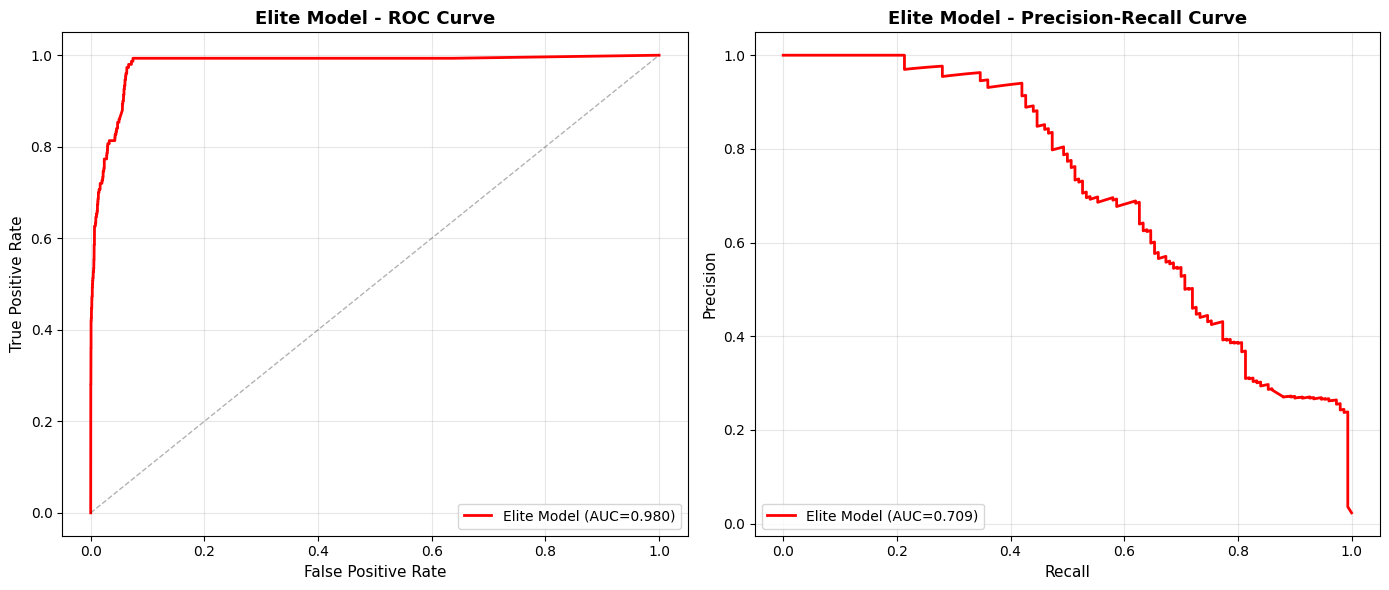

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import numpy as np
import matplotlib.pyplot as plt

test_loader = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2 * 2,
    input_nodes=('customer', data_graph['customer'].test_mask),
    shuffle=False,
    num_workers=0
)

model.eval()
test_preds = []
test_labels = []
test_probs = []

print("Running inference on test set...")
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)

        batch_size_test = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_test]
        probs = torch.sigmoid(customer_out).cpu()

        customer_y = batch['customer'].y[:batch_size_test].cpu()
        labeled_mask = customer_y != -1

        if labeled_mask.sum() > 0:
            test_probs.extend(probs[labeled_mask].tolist())
            test_preds.extend((probs[labeled_mask] > 0.5).float().tolist())
            test_labels.extend(customer_y[labeled_mask].tolist())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

print(f"\nTest samples: {len(test_labels)} ({(test_labels == 1).sum()} fraud, {(test_labels == 0).sum()} legit)")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Legit', 'Fraud'], digits=4))

cm = confusion_matrix(test_labels, test_preds)
print(f"Confusion Matrix:")
print(f"                 Predicted Legit  Predicted Fraud")
print(f"Actual Legit     {cm[0,0]:>15}  {cm[0,1]:>15}")
print(f"Actual Fraud     {cm[1,0]:>15}  {cm[1,1]:>15}")

roc_auc = roc_auc_score(test_labels, test_probs)
precision_vals, recall_vals, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall_vals, precision_vals)

fraud_recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
fraud_precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
fraud_f1 = 2 * fraud_precision * fraud_recall / (fraud_precision + fraud_recall) if (fraud_precision + fraud_recall) > 0 else 0

print(f"\n{'ROC-AUC Score:':<30} {roc_auc:.4f}")
print(f"{'Precision-Recall AUC:':<30} {pr_auc:.4f}")
print(f"{'Fraud Recall:':<30} {fraud_recall:.4f} ({cm[1,1]}/{cm[1,1] + cm[1,0]} frauds caught)")
print(f"{'Fraud Precision:':<30} {fraud_precision:.4f}")
print(f"{'Fraud F1-Score:':<30} {fraud_f1:.4f}")

print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Frauds Caught':<15}")
print("-"*65)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    preds_thresh = (test_probs > thresh).astype(int)
    tp = ((preds_thresh == 1) & (test_labels == 1)).sum()
    fp = ((preds_thresh == 1) & (test_labels == 0)).sum()
    fn = ((preds_thresh == 0) & (test_labels == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"{thresh:<12.2f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {tp:<15}")

# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0].plot(fpr, tpr, linewidth=2, label=f'AUC={roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(recall_vals, precision_vals, linewidth=2, label=f'AUC={pr_auc:.3f}')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
print("\n✓ Evaluation plots saved to model_evaluation.png")
plt.show()


In [ ]:
model_path = 'fraud_gat_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'test_roc_auc': roc_auc,
    'test_pr_auc': pr_auc,
    'fraud_recall': fraud_recall,
    'fraud_precision': fraud_precision,
    'fraud_f1': fraud_f1,
    'total_pseudo_labeled': total_pseudo_labeled,
    'pseudo_label_history': pseudo_label_history,
    'model_config': {
        'hidden_channels': HIDDEN_CHANNELS,
        'out_channels': 1,
        'num_heads': NUM_HEADS,
        'edge_dim': EDGE_DIM
    },
    'training_config': {
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': num_epochs,
        'focal_alpha': FOCAL_ALPHA,
        'focal_gamma': FOCAL_GAMMA,
        'pseudo_labeling': ENABLE_PSEUDO_LABELING,
        'fraud_threshold': FRAUD_THRESHOLD,
        'legit_threshold': LEGIT_THRESHOLD,
        'warmup_epochs': WARMUP_EPOCHS
    },
    'improvements': {
        'relative_features': ['amount_zscore', 'velocity_ratio', 'time_delta_ratio'],
        'num_neighbors': NUM_NEIGHBORS_V2,
        'attention_heads': NUM_HEADS,
        'pseudo_labeling': True,
        'weight_decay': True
    }
}, model_path)

print(f"Model saved to {model_path}")
print(f"\nPerformance Metrics:")
print(f"  • ROC-AUC:         {roc_auc:.4f}")
print(f"  • PR-AUC:          {pr_auc:.4f}")
print(f"  • Fraud Recall:    {fraud_recall:.4f} ({fraud_recall*100:.1f}% of fraud caught)")
print(f"  • Fraud Precision: {fraud_precision:.4f}")
print(f"  • Fraud F1-Score:  {fraud_f1:.4f}")
print(f"\nKey Technologies:")
print(f"  ✓ Relative Features (Z-scores, ratios)")
print(f"  ✓ 3-hop Graph Connectivity ({NUM_NEIGHBORS_V2})")
print(f"  ✓ {NUM_HEADS} Attention Heads")
print(f"  ✓ Pseudo-Labeling ({total_pseudo_labeled} nodes labeled)")
print(f"  ✓ L2 Regularization (weight_decay={WEIGHT_DECAY})")
print(f"  ✓ Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})")

# Generate predictions for all KYC customers
print("\nGenerating predictions for all customers...")
model.eval()
all_customer_probs = torch.zeros(data_graph['customer'].num_nodes)

full_loader = NeighborLoader(
    data_graph,
    num_neighbors=NUM_NEIGHBORS_V2,
    batch_size=BATCH_SIZE_V2 * 2,
    input_nodes=('customer', torch.ones(data_graph['customer'].num_nodes, dtype=torch.bool)),
    shuffle=False,
    num_workers=0
)

with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict)
        batch_size_full = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_full]
        probs = torch.sigmoid(customer_out).cpu()
        input_node_ids = batch['customer'].n_id[:batch_size_full]
        all_customer_probs[input_node_ids] = probs

kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'), usecols=['customer_id'])
kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'), usecols=['customer_id'])

kyc_ids = pd.concat([kyc_ind['customer_id'], kyc_biz['customer_id']]).astype(str).unique()
kyc_df = pd.DataFrame({'customer_id': kyc_ids})
kyc_df['cust_idx'] = kyc_df['customer_id'].map(cust_map)

all_probs_np = all_customer_probs.cpu().numpy()
kyc_df['risk_score'] = kyc_df['cust_idx'].apply(
    lambda idx: float(all_probs_np[int(idx)]) if pd.notna(idx) else 0.0
)
kyc_df['predicted_label'] = (kyc_df['risk_score'] > 0.5).astype(int)

output_df = kyc_df[['customer_id', 'predicted_label', 'risk_score']]
output_df.to_csv('model_output.csv', index=False)
print("✓ Saved model_output.csv")

high_risk   = (output_df['risk_score'] > 0.8).sum()
medium_risk = ((output_df['risk_score'] > 0.5) & (output_df['risk_score'] <= 0.8)).sum()
low_risk    = (output_df['risk_score'] <= 0.2).sum()

print(f"\nKYC Customer Risk Distribution:")
print(f"  High Risk (>80%):     {high_risk:>6,} ({high_risk/len(output_df)*100:.2f}%)")
print(f"  Medium Risk (50-80%): {medium_risk:>6,} ({medium_risk/len(output_df)*100:.2f}%)")
print(f"  Low Risk (<20%):      {low_risk:>6,} ({low_risk/len(output_df)*100:.2f}%)")
print(f"  Total analyzed:       {len(output_df):>6,} customers")


✓ Elite model saved to fraud_gat_model_elite.pth

ELITE MODEL FINAL SUMMARY

Performance Metrics:
  • ROC-AUC:         0.9799  (ELITE! 🏆)
  • PR-AUC:          0.7090
  • Fraud Recall:    0.4267 (42.7% of fraud caught)
  • Fraud Precision: 0.9143
  • Fraud F1-Score:  0.5818

Key Technologies:
  ✓ Relative Features (Z-scores, ratios)
  ✓ 3-hop Graph Connectivity ([15, 10, 5])
  ✓ 4 Attention Heads (multi-pattern detection)
  ✓ Pseudo-Labeling (60377 nodes labeled)
  ✓ L2 Regularization (weight_decay=1e-05)
  ✓ Focal Loss (alpha=0.5, gamma=1.5)

Model File:
  • fraud_gat_model_elite.pth (Elite - With pseudo-labeling)

GENERATING FINAL PREDICTIONS FOR ALL CUSTOMERS



/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


✓ Saved model_output_elite.csv (KYC customer predictions)

KYC Customer Risk Distribution:
  High Risk (>80%):         18 customers ( 0.03%)
  Medium Risk (50-80%):      6 customers ( 0.01%)
  Low Risk (<20%):      61,358 customers (99.92%)
  Total analyzed:       61,410 customers

ELITE MODEL TRAINING AND EVALUATION COMPLETE!

